# TED Material Case Studies

This notebook builds the final demonstration layer for Part 2 using manually chosen TED notices from the dataset. The goal is to show how real procurement cases can be linked to the clustered materials and pricing outputs, while staying honest about where manual interpretation of material context is still required.

In [2]:
# Import the libraries used in this notebook section.
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [3]:
# Set up project paths so files can be read and outputs can be organised consistently.
cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else cwd

processed_dir = project_root / "data" / "processed"
clustering_results_dir = project_root / "results" / "materials_clustering"
pricing_results_dir = project_root / "results" / "materials_pricing"
results_dir = project_root / "results" / "ted_case_studies"
supporting_results_dir = results_dir / "supporting"
results_dir.mkdir(parents=True, exist_ok=True)
supporting_results_dir.mkdir(parents=True, exist_ok=True)

ted_path = processed_dir / "ted_cleaned_for_cost_prediction_english.csv"
alternatives_path = pricing_results_dir / "cost_effective_alternatives.csv"
# Group similar records and evaluate the quality of the cluster structure.
cluster_cost_classes_path = pricing_results_dir / "materials_cluster_cost_classes.csv"
feature_rankings_path = clustering_results_dir / "materials_cluster_feature_rankings.csv"
cluster_representatives_path = clustering_results_dir / "supporting" / "materials_cluster_representatives.csv"

case_studies_output = results_dir / "ted_case_studies_selected.csv"
case_material_options_output = results_dir / "ted_case_material_options.csv"
case_cluster_profiles_output = supporting_results_dir / "ted_case_cluster_profiles.csv"
case_search_results_output = supporting_results_dir / "ted_case_search_results.csv"

print("TED file:", ted_path)
print("Alternatives file:", alternatives_path)
print("Cluster cost classes file:", cluster_cost_classes_path)
print("Results directory:", results_dir)

TED file: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\data\processed\ted_cleaned_for_cost_prediction_english.csv
Alternatives file: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_pricing\cost_effective_alternatives.csv
Cluster cost classes file: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_pricing\materials_cluster_cost_classes.csv
Results directory: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\ted_case_studies


In [4]:
# Check that the expected input files are available before continuing.
for path in [ted_path, alternatives_path, cluster_cost_classes_path, feature_rankings_path]:
    if not path.exists():
        # Handle missing values so later transformations and models do not fail.
        raise FileNotFoundError(f"Missing required input file: {path}")

## Load TED and material-option inputs

In [5]:
# Load the dataset needed for the next analysis step.
ted_df = pd.read_csv(ted_path, low_memory=False)
alternatives_df = pd.read_csv(alternatives_path)
# Group similar records and evaluate the quality of the cluster structure.
cluster_cost_classes_df = pd.read_csv(cluster_cost_classes_path)
feature_rankings_df = pd.read_csv(feature_rankings_path)
cluster_representatives_df = pd.read_csv(cluster_representatives_path) if cluster_representatives_path.exists() else pd.DataFrame()

# Handle missing values so later transformations and models do not fail.
ted_df["TITLE"] = ted_df["TITLE"].fillna("").astype(str)
# Convert values into analysis-friendly numeric, date, or text formats.
ted_df["CPV"] = ted_df["CPV"].astype(str)
# Filter the data to keep the records relevant for this step.
ted_df["TYPE_OF_CONTRACT"] = ted_df["TYPE_OF_CONTRACT"].fillna("Unknown")
ted_df["MAIN_ACTIVITY"] = ted_df["MAIN_ACTIVITY"].fillna("Unknown")
ted_df["search_text"] = (
    ted_df["TITLE"].fillna("") + " " + ted_df["TYPE_OF_CONTRACT"].fillna("") + " " + ted_df["CPV"].fillna("")
).str.lower()
ted_columns_lower = {column.lower(): column for column in ted_df.columns}
ted_notice_id_column = ted_columns_lower.get("id_notice_can")

# Inspect the data to confirm the structure and values look reasonable.
print("TED shape:", ted_df.shape)
print("TED notice id column:", ted_notice_id_column)
display(ted_df.head())

print("Alternatives shape:", alternatives_df.shape)
display(alternatives_df.head())

TED shape: (46503, 16)
TED notice id column: None


,TITLE,CPV,ADDITIONAL_CPVS,TYPE_OF_CONTRACT,TOP_TYPE,MAIN_ACTIVITY,CAE_TYPE,ISO_COUNTRY_CODE,TAL_LOCATION_NUTS,LOTS_NUMBER,VALUE_EURO,DISPATCH_YEAR,DISPATCH_MONTH,DISPATCH_QUARTER,LOG_VALUE_EURO,search_text
0,Unknown,85000000,Unknown,S,NIC,Health,6,AT,AT,1.0,16257000.00,2022,12,4,16.604034,unknown s 85000000
1,Supply of various vehicles for the Mobile Park of the Provincial Council of Alicante - L2: “Supply of two electric vans with folding interior ramp”,34144900,Unknown,U,OPE,General public\services,3,ES,ES521,1.0,109000.00,2022,12,4,11.599112,supply of various vehicles for the mobile park of the provincial council of alicante - l2: “supply of two electric vans with folding interior ramp” u 34144900
2,Laboratory equipment,38000000,42900000,U,OPE,Health,6,SK,SK,4.0,1942083.33,2022,12,4,14.479272,laboratory equipment u 38000000
3,Equipment for sample processing,38000000,42900000,U,OPE,Health,6,SK,SK,4.0,1942083.33,2022,12,4,14.479272,equipment for sample processing u 38000000
4,Equipment for the needs of the experimental menagerie,38000000,42900000,U,OPE,Health,6,SK,SK,4.0,1942083.33,2022,12,4,14.479272,equipment for the needs of the experimental menagerie u 38000000


Alternatives shape: (213, 26)


,cluster_label,source_row_index,source_material_id,source_formula_pretty_x,neighbor_row_index,neighbor_material_id,neighbor_formula_pretty,similarity_distance,similarity_rank_within_source,similarity_distance_percentile,similarity_level,source_formula_pretty_y,source_cost,source_unit,source_year,source_cost_class,source_cost_rank_within_cluster,neighbor_formula_pretty_verified,neighbor_cost,neighbor_unit,neighbor_year,neighbor_cost_class,neighbor_cost_rank_within_cluster,cost_difference,cost_saving,is_lower_cost_alternative
0,4,7502,mp-1018029,CuPd,33310,mp-6938,ZnRh,0.306505,1,0.2,high_similarity,CuPd,9947.305000,($/mt),2025.0,medium_cost,8,ZnRh,2867.528333,($/mt),2025.0,medium_cost,6,-7079.776667,7079.776667,True
1,1,22128,mp-1025039,PbS2,187,mp-23231,AgBr,0.489930,1,0.2,high_similarity,PbS2,1962.235000,($/mt),2025.0,low_cost,4,AgBr,39.804667,($/troy oz),2025.0,low_cost,1,-1922.430333,1922.430333,True
2,4,33091,mp-1047156,Zn(CuO2)2,88,mp-4691,Ag2CO3,0.303195,2,0.4,moderate_similarity,Zn(CuO2)2,2867.528333,($/mt),2025.0,medium_cost,6,Ag2CO3,39.804667,($/troy oz),2025.0,low_cost,1,-2827.723667,2827.723667,True
3,3,21592,mp-1070761,Ni(BW)2,33088,mp-28786,Zn(BIr)2,0.219849,2,0.4,moderate_similarity,Ni(BW)2,15162.158333,($/mt),2025.0,high_cost,9,Zn(BIr)2,2867.528333,($/mt),2025.0,medium_cost,6,-12294.630000,12294.630000,True
4,4,21675,mp-1078540,Ni6Ge2B,500,mp-1228832,AlNi6Ge,0.128342,3,0.6,moderate_similarity,Ni6Ge2B,15162.158333,($/mt),2025.0,high_cost,9,AlNi6Ge,2631.695833,($/mt),2025.0,low_cost,5,-12530.462500,12530.462500,True


## Input the TED case details here

This is the only section you should need to edit for a different case. Update the case details in the input template below, rerun the notebook, and the outputs will be regenerated for the new TED notice. Candidate material options will only appear when the chosen case can be linked to supported material clusters and price-proxy data.

In [6]:
# Edit this input template for a new TED case.
# You should normally only need to change the values in this cell.

CASE_STUDY_INPUTS = [
    {
        "case_name": "Copper-Core PVC Power Cables",
        "id_notice_can": 20239408,
        "cpv_code": "31320000",
        "english_title": "Underground cables, copper core, 0.6/1 kV - PVC insulation and sheath",
        "material_context": "Electrical supply case focused on copper-core power cables with PVC insulation. This gives a clear conductor material and insulation context for comparing candidate alternatives.",
        "target_clusters": [3, 4],
        "preferred_similarity_levels": ["high_similarity", "moderate_similarity"],
        "max_options": 10,
    },
]

CASE_STUDY_CONFIG = CASE_STUDY_INPUTS
pd.DataFrame(CASE_STUDY_INPUTS)

,case_name,id_notice_can,cpv_code,english_title,material_context,target_clusters,preferred_similarity_levels,max_options
0,Copper-Core PVC Power Cables,20239408,31320000,"Underground cables, copper core, 0.6/1 kV - PVC insulation and sheath",Electrical supply case focused on copper-core power cables with PVC insulation. This gives a clear conductor material and insulation context for comparing candidate alternatives.,"[3, 4]","[high_similarity, moderate_similarity]",10


## Retrieve the selected TED notice from the English TED dataset

The notebook uses the input details above to find the matching TED case in the English dataset and attach the extra reporting fields needed for the final case-study outputs.

In [7]:
# Filter the data to keep the records relevant for this step.
selected_case_rows = []
search_result_frames = []

for config in CASE_STUDY_CONFIG:
    # Convert values into analysis-friendly numeric, date, or text formats.
    case_df = ted_df[ted_df["CPV"].astype(str).eq(str(config["cpv_code"]))].copy()

    if ted_notice_id_column is not None:
        notice_match_df = ted_df[ted_df[ted_notice_id_column].astype(str).eq(str(config["id_notice_can"]))].copy()
        if not notice_match_df.empty:
            case_df = notice_match_df

    if case_df.empty:
        fallback_df = ted_df[ted_df["CPV"].astype(str).eq(str(config["cpv_code"]))].copy()
        fallback_df["case_name"] = config["case_name"]
        fallback_df["selection_status"] = "fallback_cpv_search_match"
        search_result_frames.append(fallback_df)
        continue

    # Summarise the data so patterns can be compared more easily.
    case_df = case_df.sort_values(["DISPATCH_YEAR", "VALUE_EURO"], ascending=[False, False]).head(1).copy()
    case_df["case_name"] = config["case_name"]
    case_df["selection_status"] = "selected_from_english_dataset" if ted_notice_id_column is not None else "selected_by_cpv_match"
    case_df["english_title"] = config["english_title"]
    case_df["material_context"] = config["material_context"]
    case_df["target_clusters"] = str(config["target_clusters"])
    selected_case_rows.append(case_df.iloc[0].to_dict())

selected_case_studies_df = pd.DataFrame(selected_case_rows)
# Combine related tables so each record has the fields needed for analysis.
case_search_results_df = pd.concat(search_result_frames, ignore_index=True) if search_result_frames else pd.DataFrame()

# Inspect the data to confirm the structure and values look reasonable.
display(selected_case_studies_df)
display(case_search_results_df.head(20))

,TITLE,CPV,ADDITIONAL_CPVS,TYPE_OF_CONTRACT,TOP_TYPE,MAIN_ACTIVITY,CAE_TYPE,ISO_COUNTRY_CODE,TAL_LOCATION_NUTS,LOTS_NUMBER,VALUE_EURO,DISPATCH_YEAR,DISPATCH_MONTH,DISPATCH_QUARTER,LOG_VALUE_EURO,search_text,case_name,selection_status,english_title,material_context,target_clusters
0,"Earth cables, Cu core, 0.6/1 kV - insulation and PVC jacket",31320000,Unknown,U,NIC,Electricity,4,CZ,Unknown,3.0,185548.74,2023,1,1,12.131078,"earth cables, cu core, 0.6/1 kv - insulation and pvc jacket u 31320000",Copper-Core PVC Power Cables,selected_by_cpv_match,"Underground cables, copper core, 0.6/1 kV - PVC insulation and sheath",Electrical supply case focused on copper-core power cables with PVC insulation. This gives a clear conductor material and insulation context for comparing candidate alternatives.,"[3, 4]"


""


## Confirm the selected case-study record

The selected TED notice now carries both the original title and the English translation used for reporting. You can add more cases later by appending to `CASE_STUDY_CONFIG`, provided the chosen notices can be linked to supported material clusters.

In [8]:
selected_case_studies_df = selected_case_studies_df[[
    column for column in [
        "case_name", "CPV", "TYPE_OF_CONTRACT", "VALUE_EURO", "TITLE",
        "english_title", "material_context", "target_clusters",
        "MAIN_ACTIVITY", "TOP_TYPE", "DISPATCH_YEAR", "DISPATCH_MONTH", "DISPATCH_QUARTER"
    ] if column in selected_case_studies_df.columns
]].copy()

# Inspect the data to confirm the structure and values look reasonable.
display(selected_case_studies_df)

,case_name,CPV,TYPE_OF_CONTRACT,VALUE_EURO,TITLE,english_title,material_context,target_clusters,MAIN_ACTIVITY,TOP_TYPE,DISPATCH_YEAR,DISPATCH_MONTH,DISPATCH_QUARTER
0,Copper-Core PVC Power Cables,31320000,U,185548.74,"Earth cables, Cu core, 0.6/1 kV - insulation and PVC jacket","Underground cables, copper core, 0.6/1 kV - PVC insulation and sheath",Electrical supply case focused on copper-core power cables with PVC insulation. This gives a clear conductor material and insulation context for comparing candidate alternatives.,"[3, 4]",Electricity,NIC,2023,1,1


## Build cluster profiles for the targeted material groups

In [9]:
# Summarise the data so patterns can be compared more easily.
cluster_feature_rank_pivot_df = feature_rankings_df.pivot(
    # Group similar records and evaluate the quality of the cluster structure.
    index="cluster_label",
    columns="rank_position",
    values="feature_name",
).rename(columns={1: "top_feature_1", 2: "top_feature_2", 3: "top_feature_3"}).reset_index()

cluster_profile_df = cluster_feature_rank_pivot_df.copy()
if not cluster_representatives_df.empty:
    representatives_summary_df = (
        cluster_representatives_df.groupby("cluster_label")["formula_pretty"]
        .apply(lambda values: ", ".join(pd.Series(values).dropna().astype(str).head(5)))
        .reset_index(name="representative_materials")
    )
    # Combine related tables so each record has the fields needed for analysis.
    cluster_profile_df = cluster_profile_df.merge(representatives_summary_df, on="cluster_label", how="left")

# Inspect the data to confirm the structure and values look reasonable.
display(cluster_profile_df)

,cluster_label,top_feature_1,top_feature_2,top_feature_3,representative_materials
0,0,volume,nsites,nelements,"Ba8B5N10F, CdAs2(XeF5)4, Sb3Au(XeF9)2, BaSc3AgS6, MgAs2(XeF5)4"
1,1,density_atomic,is_metal_flag,density,"BaTeS3, MoBr3O, CsBSe3, NbSeBr3, BaPSe3"
2,2,formation_energy_per_atom,band_gap,density_atomic,"BaMo2(PO6)2, MgVBiO5, RbSn2(PO4)3, LiP3(WO6)2, Nd2Mo(SeO5)2"
3,3,energy_per_atom,density,nelements,"SmIn2Ir, Y3(ZnAu2)2, NdIn2Ir, YTlPd, Tb2CuPt"
4,4,is_metal_flag,band_gap,formation_energy_per_atom,"Er3Fe2Si3, Zr4Ni3As8, YGaRh, ZrGeMo, Er3CoSi3"


## Generate case-specific material options

Each case input is linked to the target clusters defined in the input cell above. The resulting options are drawn from lower-cost alternatives already derived inside technically similar material groups, so changing the input case should be enough to regenerate a new output shortlist when the supporting data is available.

In [10]:
# Filter the data to keep the records relevant for this step.
case_option_frames = []
for config in CASE_STUDY_CONFIG:
    case_name = config["case_name"]
    # Define the modelling target and input features.
    target_clusters = config["target_clusters"]
    preferred_similarity_levels = config["preferred_similarity_levels"]
    max_options = config["max_options"]

    case_options_df = alternatives_df[
        # Group similar records and evaluate the quality of the cluster structure.
        alternatives_df["cluster_label"].isin(target_clusters)
        & alternatives_df["similarity_level"].isin(preferred_similarity_levels)
    ].copy()

    if case_options_df.empty:
        continue

    case_options_df["case_name"] = case_name
    case_options_df["cpv_code"] = str(config["cpv_code"])
    case_options_df["english_title"] = config["english_title"]
    case_options_df["material_context"] = config["material_context"]
    # Summarise the data so patterns can be compared more easily.
    case_options_df = case_options_df.sort_values(
        ["cluster_label", "similarity_level", "cost_saving"],
        ascending=[True, True, False],
    ).groupby("cluster_label", as_index=False).head(max_options)
    case_option_frames.append(case_options_df)

# Combine related tables so each record has the fields needed for analysis.
case_material_options_df = pd.concat(case_option_frames, ignore_index=True) if case_option_frames else pd.DataFrame()

# Inspect the data to confirm the structure and values look reasonable.
display(case_material_options_df.head(20))

,cluster_label,source_row_index,source_material_id,source_formula_pretty_x,neighbor_row_index,neighbor_material_id,neighbor_formula_pretty,similarity_distance,similarity_rank_within_source,similarity_distance_percentile,similarity_level,source_formula_pretty_y,source_cost,source_unit,source_year,source_cost_class,source_cost_rank_within_cluster,neighbor_formula_pretty_verified,neighbor_cost,neighbor_unit,neighbor_year,neighbor_cost_class,neighbor_cost_rank_within_cluster,cost_difference,cost_saving,is_lower_cost_alternative,case_name,cpv_code,english_title,material_context
0,3,26760,mp-1194504,Sn3Ir2Se3,140,mp-5710,Ag3Te2Au,0.630942,1,0.2,high_similarity,Sn3Ir2Se3,34058.835833,($/mt),2025.0,high_cost,10,Ag3Te2Au,39.804667,($/troy oz),2025.0,low_cost,1,-34019.031167,34019.031167,True,Copper-Core PVC Power Cables,31320000,"Underground cables, copper core, 0.6/1 kV - PVC insulation and sheath",Electrical supply case focused on copper-core power cables with PVC insulation. This gives a clear conductor material and insulation context for comparing candidate alternatives.
1,3,21679,mp-1194082,Ni6W6C,33207,mp-1215752,Zn6B5Ir11,0.318896,1,0.2,high_similarity,Ni6W6C,15162.158333,($/mt),2025.0,high_cost,9,Zn6B5Ir11,2867.528333,($/mt),2025.0,medium_cost,6,-12294.630000,12294.630000,True,Copper-Core PVC Power Cables,31320000,"Underground cables, copper core, 0.6/1 kV - PVC insulation and sheath",Electrical supply case focused on copper-core power cables with PVC insulation. This gives a clear conductor material and insulation context for comparing candidate alternatives.
2,3,7405,mp-1105186,Cu3B5Pt9,33223,mp-579677,ZnB3Ir4,0.208278,1,0.2,high_similarity,Cu3B5Pt9,9947.305000,($/mt),2025.0,high_cost,8,ZnB3Ir4,2867.528333,($/mt),2025.0,medium_cost,6,-7079.776667,7079.776667,True,Copper-Core PVC Power Cables,31320000,"Underground cables, copper core, 0.6/1 kV - PVC insulation and sheath",Electrical supply case focused on copper-core power cables with PVC insulation. This gives a clear conductor material and insulation context for comparing candidate alternatives.
3,3,7505,mp-644311,CuPt,33281,mp-1206819,ZnIr,0.139316,1,0.2,high_similarity,CuPt,9947.305000,($/mt),2025.0,high_cost,8,ZnIr,2867.528333,($/mt),2025.0,medium_cost,6,-7079.776667,7079.776667,True,Copper-Core PVC Power Cables,31320000,"Underground cables, copper core, 0.6/1 kV - PVC insulation and sheath",Electrical supply case focused on copper-core power cables with PVC insulation. This gives a clear conductor material and insulation context for comparing candidate alternatives.
4,3,21666,mp-30811,Ni4W,7422,mp-12086,Cu3Pt,0.305433,1,0.2,high_similarity,Ni4W,15162.158333,($/mt),2025.0,high_cost,9,Cu3Pt,9947.305000,($/mt),2025.0,high_cost,8,-5214.853333,5214.853333,True,Copper-Core PVC Power Cables,31320000,"Underground cables, copper core, 0.6/1 kV - PVC insulation and sheath",Electrical supply case focused on copper-core power cables with PVC insulation. This gives a clear conductor material and insulation context for comparing candidate alternatives.
5,3,521,mp-10909,AlRe2,21995,mp-2082,PIr2,0.256811,1,0.2,high_similarity,AlRe2,2631.695833,($/mt),2025.0,low_cost,5,PIr2,152.500000,($/mt),2025.0,low_cost,2,-2479.195833,2479.195833,True,Copper-Core PVC Power Cables,31320000,"Underground cables, copper core, 0.6/1 kV - PVC insulation and sheath",Electrical supply case focused on copper-core power cables with PVC insulation. This gives a clear conductor material and insulation context for comparing candidate alternatives.
6,3,520,mp-1228815,AlRe,22016,mp-2420,PW,0.225802,1,0.2,high_similarity,AlRe,2631.695833,($/mt),2025.0,low_cost,5,PW,152.500000,($/mt),2025.0,low_cost,2,-2479.195833,2479.195833,True,Copper-Core PVC Power Cables,31320000,"Underground cables, copper core, 0.6/1 kV - PVC insulation and sheath",Electrical supply case focused on copper-core power cables with PVC insulation. This gives a clear conductor material and insulation context for comparing candidate alternatives.
7,

## Summarise final case-study recommendations

In [11]:
case_summary_df = (
    # Summarise the data so patterns can be compared more easily.
    case_material_options_df.groupby(["case_name", "cluster_label"])
    .agg(
        option_count=("neighbor_material_id", "count"),
        median_cost_saving=("cost_saving", "median"),
        max_cost_saving=("cost_saving", "max"),
    )
    .reset_index()
)

# Inspect the data to confirm the structure and values look reasonable.
display(case_summary_df)

,case_name,cluster_label,option_count,median_cost_saving,max_cost_saving
0,Copper-Core PVC Power Cables,3,10,7079.776667,34019.031167
1,Copper-Core PVC Power Cables,4,10,12530.462500,24111.530833


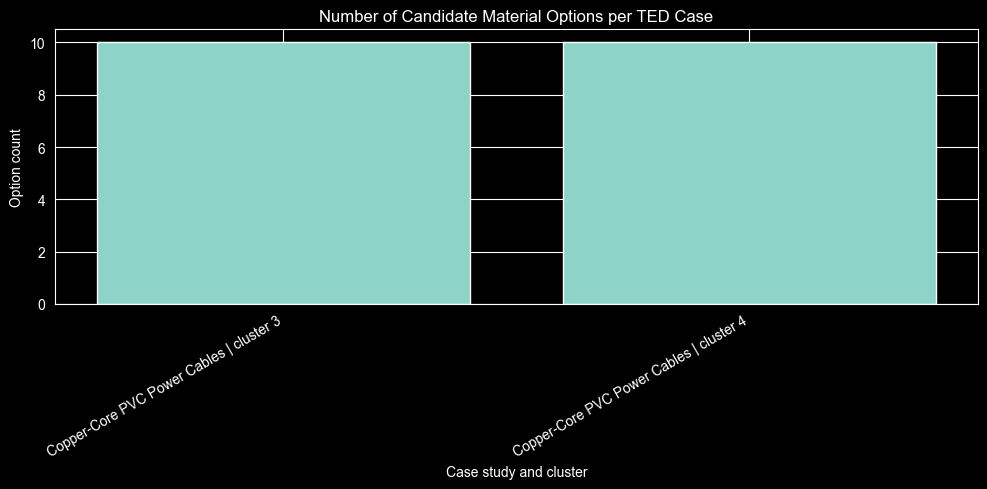

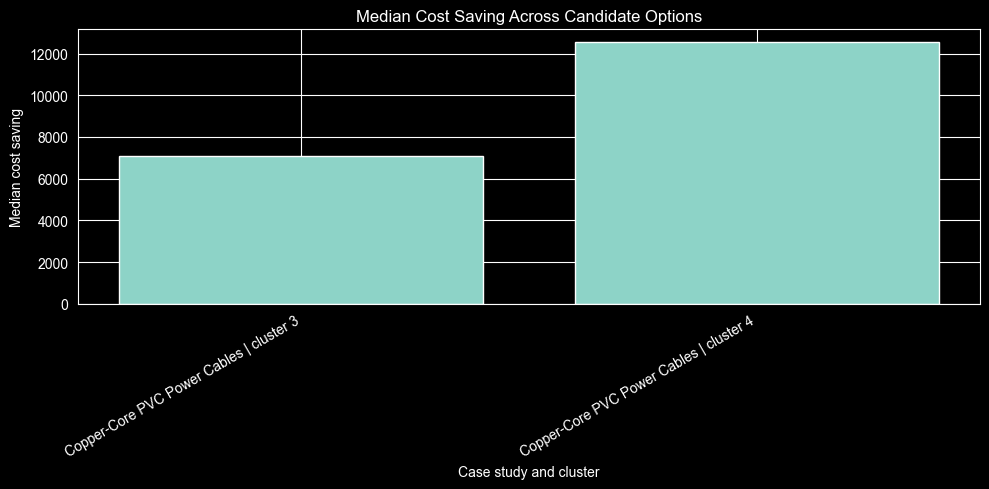

In [12]:
if not case_summary_df.empty:
    plot_df = case_summary_df.copy()
    # Convert values into analysis-friendly numeric, date, or text formats.
    plot_labels = plot_df["case_name"] + " | cluster " + plot_df["cluster_label"].astype(str)

    # Plot the result so the pattern is easier to interpret visually.
    plt.figure(figsize=(10, 5))
    plt.bar(plot_labels, plot_df["option_count"])
    plt.title("Number of Candidate Material Options per TED Case")
    plt.xlabel("Case study and cluster")
    plt.ylabel("Option count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(plot_labels, plot_df["median_cost_saving"])
    plt.title("Median Cost Saving Across Candidate Options")
    plt.xlabel("Case study and cluster")
    plt.ylabel("Median cost saving")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## Save case-study outputs

The selected TED notice, English translation, and candidate material options are saved as the final showcase layer for Part 2. For a different case, update the input cell near the top of the notebook and rerun the notebook from there.

In [13]:
# Save the processed output so later notebooks or report sections can reuse it.
selected_case_studies_df.to_csv(case_studies_output, index=False)
case_material_options_df.to_csv(case_material_options_output, index=False)
# Group similar records and evaluate the quality of the cluster structure.
cluster_profile_df.to_csv(case_cluster_profiles_output, index=False)
case_search_results_df.to_csv(case_search_results_output, index=False)

print(f"Saved selected case studies to: {case_studies_output}")
print(f"Saved case material options to: {case_material_options_output}")
print(f"Saved supporting cluster profiles to: {case_cluster_profiles_output}")
print(f"Saved supporting case search results to: {case_search_results_output}")

Saved selected case studies to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\ted_case_studies\ted_case_studies_selected.csv
Saved case material options to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\ted_case_studies\ted_case_material_options.csv
Saved supporting cluster profiles to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\ted_case_studies\supporting\ted_case_cluster_profiles.csv
Saved supporting case search results to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\ted_case_studies\supporting\ted_case_search_results.csv
